<h1 align = 'center'> Assignment 8: Probability Concepts
(Questions)
</h1>

<hr>

<h2 align = 'center'>Part 1: Handling missing values & Basic
concepts in Probability</h2>


<hr>

### Import necessary libraries, load the 'Cars.csv' dataset, display a data sample, determine dataset dimensions, and determine the summary statistics for quantitative and qualtitative columns.

In [1]:
#import all required libraries
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import math

In [2]:
#Read and show the file 
df = pd.read_csv('Cars.csv')
df.head(5)

,carname,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130.0,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130.0,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152.0,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109.0,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136.0,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
#Determine the dataset dimension
df.shape

(205, 24)

In [4]:
#use describe function for qualitative columns
df.describe(include = 'O')

,carname,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
count,205,205,205,205,205,205,205,205,205,205
unique,147,2,2,2,5,3,2,7,7,8
top,toyota corona,gas,std,four,sedan,fwd,front,ohc,four,mpfi
freq,6,185,168,115,96,120,202,148,159,94


In [5]:
#use describe function for quantitative columns
df.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,194.000000,205.000000,185.000000,190.000000,205.000000,185.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,98.669588,174.049268,65.932973,53.738947,2555.565854,124.081081,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,5.934168,12.337289,2.113143,2.470452,520.680204,38.528771,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,94.500000,166.300000,64.200000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,97.000000,173.200000,65.500000,54.100000,2414.000000,110.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,101.800000,183.100000,66.600000,55.575000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,120.900000,208.100000,72.300000,59.800000,4066.000000,308.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


### Q1: How many null values are there in each column?

In [6]:
df.isnull().sum()

carname              0
fueltype             0
aspiration           0
doornumber           0
carbody              0
drivewheel           0
enginelocation       0
wheelbase           11
carlength            0
carwidth            20
carheight           15
curbweight           0
enginetype           0
cylindernumber       0
enginesize          20
fuelsystem           0
boreratio            0
stroke               0
compressionratio     0
horsepower           0
peakrpm              0
citympg              0
highwaympg           0
price                0
dtype: int64

### Q1_1: Replace the null value of column "wheelbase" with the max value of the same column

In [7]:
df['wheelbase'] = df['wheelbase'].fillna(df['wheelbase'].max())

### Q1_2: Replace the null value of column "carwidth" with the Min value of the same column

In [8]:
df['carwidth'] = df['carwidth'].fillna(df['carwidth'].min())

### Q1_3: Use Linear Interpolation to change the null value of column "carheight"

In [9]:
df['carheight'] = df['carheight'].interpolate(method = 'linear')

### Q1_4: Replace the null value of column "enginesize" with the mode of the same column and check how many null values we have

In [10]:
df['enginesize'] = df['enginesize'].fillna(df['enginesize'].mode()[0])

df.isnull().sum()

### Q2: What is the Probability that the Car is Sedan ? (1 mark)

In [11]:
total = df.shape[0]
sedan = len(df[df['carbody'] == 'sedan'])
probab = round(sedan/total, 3)
probab

0.468

### Q3: What is the Probability that the car is Sedan and works with gas ?

In [12]:
sedan_gas = len(df[(df['carbody'] == 'sedan') & (df['fueltype'] == 'gas')])
probab = round(sedan_gas/total, 3)
probab

0.395

### Q4:What is the probability that a car is Sedan given it is a gas fuel type?

In [13]:
pd.crosstab(df['carbody'], df['fueltype'], margins = True)

fueltype,diesel,gas,All
carbody,,,
convertible,0,6,6
hardtop,1,7,8
hatchback,1,69,70
sedan,15,81,96
wagon,3,22,25
All,20,185,205


In [14]:
gas = 185/total
sedan_and_gas = 81/total
probab = round(sedan_and_gas/gas, 3)
probab

0.438

### Q5: Given that the car height is higher than 50, find the probability that the car engine size is greater than 130?

In [15]:
engine_gt_130 = len(df[df['carheight'] > 50])
car_height_engine = len(df[(df['carheight'] > 50)&(df['enginesize'] > 130)])
probab = round(car_height_engine/engine_gt_130, 3)
probab

0.292

<hr>

<h2 align = 'center'>Part 2: Probability Functions</h2>

<hr>

### Q6: Load dataset 'students.csv' and show first rows, shape, and compute the skewness.

In [16]:
df = pd.read_csv('students.csv')
df.head(5)

,stud.id,name,gender,age,height,weight,religion,nc.score,semester,major,minor,score1,score2,online.tutorial,graduated,salary
0,833917,"Gonzales, Christina",Female,19,160,64.8,Muslim,1.91,1st,Political Science,Social Sciences,NaN,NaN,0,0,NaN
1,898539,"Lozano, T'Hani",Female,19,172,73.0,Other,1.56,2nd,Social Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN
2,379678,"Williams, Hanh",Female,22,168,70.6,Protestant,1.24,3rd,Social Sciences,Mathematics and Statistics,45.0,46.0,0,0,NaN
3,807564,"Nem, Denzel",Male,19,183,79.7,Other,1.37,2nd,Environmental Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN
4,383291,"Powell, Heather",Female,21,175,71.4,Catholic,1.46,1st,Environmental Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN


In [17]:
df.shape

(8239, 16)

In [27]:
df.skew(numeric_only = True)

stud.id            0.018612
age                4.427823
height            -0.009244
weight             0.651004
nc.score           0.446834
score1            -0.318819
score2            -0.304878
online.tutorial    0.467502
graduated          1.403900
salary             0.273835
dtype: float64

### Q7: What is the probability that the salary is greater than 20000 and less than 30000 ?

1. Identify the distribution by
- Plotting Histogram
- calculate the skewness
- Which distribution does this data follow?
2. Compute mean and std
3. Convert to Z-scores
4. Use CDF difference with the use of the right distribution function from scipy.stats

<Axes: >

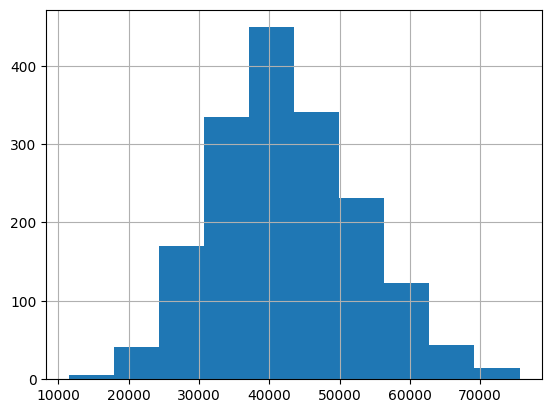

In [19]:
#1
#histogram
df['salary'].hist()

In [20]:
#skewness
print(df['salary'].skew())

0.273835141614412


#### Answer: The distribuiton of the salary is normal

In [21]:
#2
mean = df['salary'].mean()
std = df['salary'].std()

z1 = (30000 - mean)/std
z2 = (20000 - mean)/std

p = stats.norm.cdf(z1) - stats.norm.cdf(z2)
p.item()

0.09814325462173674

### Q8: A factory produces 200 chips with defect rate 8%. Answer the following questions:

1. What is the distribution name of this problem, based on the following questions ?
2. What is the probability of getting exactly 14 defective chips ?
3. At least 14 defective ?
4. At most 15 defective ?
5. Expected defects and standard deviation

#### 1- The distribution name of this problem is binomial

In [22]:
#2
p1 = stats.binom.pmf(14, 200, 0.08)
p1.item()

0.09541156492261971

In [23]:
#3
p2 = 1 - stats.binom.cdf(13, 200, 0.08)
p2.item()

0.7357078859493741

In [24]:
#4
p3 = stats.binom.cdf(15, 200, 0.08)
p3.item()

0.4625822359332888

In [25]:
#5
avg, variance = stats.binom.stats(200,0.08)
print(avg)
print(math.sqrt(variance))

16.0
3.8366652186501757


In [ ]:
mean = df['salary'].mean()
std = df['salary'].std()
z1 = (30000 - mean)/std
z2 = (20000 - mean)/std
print(stats.norm.cdf(30000) - )